In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [3]:
file_path = "/Users/jackpapciak/Columbia/Computational_Epidemiology/project/comp-epidemiology-final-project/data/external/uti_cohort_2026-04-18.csv"

df = pd.read_csv(file_path)

print(df.shape)
df.head()

(49108, 31)


,person_id,index_uti_date,age_at_index,gender_concept_id,recurrent_uti_90d_flag,first_recurrent_uti_date,any_abx_0_10d_flag,first_abx_0_10d_date,first_abx_0_10d_concept_id,num_distinct_abx_0_10d,...,ckd_1yr_count,htn_ever_flag,htn_1yr_flag,htn_1yr_count,kidney_failure_ever_flag,kidney_failure_1yr_flag,kidney_failure_1yr_count,diabetes_ever_flag,diabetes_1yr_flag,diabetes_1yr_count
0,55,2009-12-16,85,8532,0,NaN,0,NaN,NaN,0,...,0,0,0,0,0,0,0,1,1,1
1,82,2008-09-28,80,8507,0,NaN,0,NaN,NaN,0,...,0,1,1,1,0,0,0,1,1,7
2,89,2009-11-28,98,8532,0,NaN,0,NaN,NaN,0,...,0,0,0,0,0,0,0,1,1,1
3,97,2010-06-08,81,8507,0,NaN,0,NaN,NaN,0,...,0,1,1,1,0,0,0,1,1,8
4,98,2010-06-30,67,8507,1,2010-07-30,0,NaN,NaN,0,...,0,1,0,0,0,0,0,1,1,2


In [4]:
# Drop obvious non-feature columns
drop_cols = [
    "person_id",
    "index_uti_date",
    "first_recurrent_uti_date",
    "first_abx_0_10d_date"
]

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Fill missing values
df_model = df_model.fillna(0)

df_model.head()

,age_at_index,gender_concept_id,recurrent_uti_90d_flag,any_abx_0_10d_flag,first_abx_0_10d_concept_id,num_distinct_abx_0_10d,repeat_abx_11_30d_flag,er_30d_flag,total_visits_1yr,outpatient_visits_1yr,...,ckd_1yr_count,htn_ever_flag,htn_1yr_flag,htn_1yr_count,kidney_failure_ever_flag,kidney_failure_1yr_flag,kidney_failure_1yr_count,diabetes_ever_flag,diabetes_1yr_flag,diabetes_1yr_count
0,85,8532,0,0,0.0,0,0,0,11,2,...,0,0,0,0,0,0,0,1,1,1
1,80,8507,0,0,0.0,0,0,0,39,5,...,0,1,1,1,0,0,0,1,1,7
2,98,8532,0,0,0.0,0,0,0,20,7,...,0,0,0,0,0,0,0,1,1,1
3,81,8507,0,0,0.0,0,0,0,33,3,...,0,1,1,1,0,0,0,1,1,8
4,67,8507,1,0,0.0,0,0,0,24,3,...,0,1,0,0,0,0,0,1,1,2


In [5]:
target = "recurrent_uti_90d_flag"

X = df_model.drop(columns=[target])
y = df_model[target]

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Features: (49108, 26)
Target distribution:
recurrent_uti_90d_flag
0    0.849271
1    0.150729
Name: proportion, dtype: float64


In [6]:
# Convert gender_concept_id to categorical
if "gender_concept_id" in X.columns:
    X = pd.get_dummies(X, columns=["gender_concept_id"], drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"  # helpful if classes are imbalanced
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC-AUC: 0.6287642068465013

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.66      0.76      8342
           1       0.21      0.51      0.30      1480

    accuracy                           0.64      9822
   macro avg       0.55      0.59      0.53      9822
weighted avg       0.78      0.64      0.69      9822


Confusion Matrix:
[[5523 2819]
 [ 719  761]]


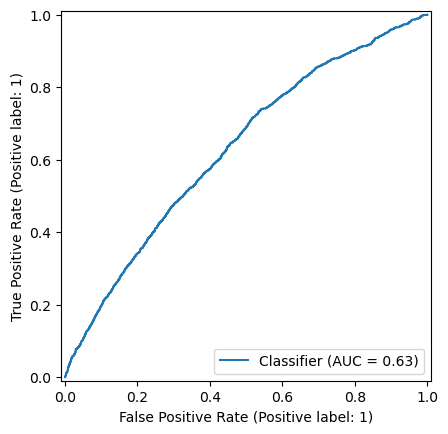

In [11]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

In [12]:
feature_names = X.columns

coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
})

coefficients["abs_coef"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values(by="abs_coef", ascending=False)

coefficients.head(20)

,feature,coefficient,abs_coef
6,total_visits_1yr,0.360177,0.360177
23,diabetes_1yr_flag,0.189567,0.189567
12,prior_distinct_abx_count_1yr,0.185772,0.185772
11,prior_abx_exposure_count_1yr,-0.163098,0.163098
22,diabetes_ever_flag,-0.136198,0.136198
3,num_distinct_abx_0_10d,0.129428,0.129428
10,prior_uti_count_1yr,0.123747,0.123747
1,any_abx_0_10d_flag,-0.119108,0.119108
14,ckd_1yr_flag,0.111007,0.111007
9,inpatient_visits_1yr,0.091419,0.091419


In [15]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [16]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [17]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.6222593907741354

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      8342
           1       0.60      0.01      0.01      1480

    accuracy                           0.85      9822
   macro avg       0.73      0.50      0.47      9822
weighted avg       0.81      0.85      0.78      9822


Confusion Matrix:
[[8336    6]
 [1471    9]]
